In [3]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt

### Załadowanie danych

In [4]:
image_dataset_from_directory = tf.keras.utils.image_dataset_from_directory

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    "dataset/train",            
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    "dataset/valid",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    "dataset/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 1767 files belonging to 6 classes.
Found 504 files belonging to 6 classes.
Found 253 files belonging to 6 classes.


### Sprawdzenie klas

In [5]:
class_names = test_ds.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### Sprawdzenie poprawności kształtu etykiet i rozmiaru batchu

In [6]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


### Wyświetlenie obrazu do sprawdzenia poprawności ich odczytu

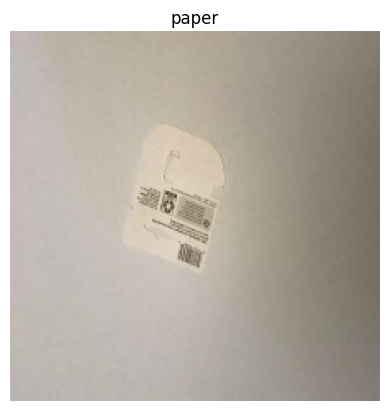

In [7]:
for images, labels in train_ds.take(1):
    plt.imshow(images[0].numpy().astype("uint8"))
    plt.title(class_names[labels[0]])
    plt.axis("off")
    plt.show()

### Optymalizacja wczytywania danych (by trening szedł szybciej)

In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

### Augmentacja datasetu (urozmaicenie)

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

### Przygotowanie gotowego modelu z transfer learningiem (EfficientNetB0)

In [10]:
base_model = tf.keras.applications.EfficientNetB0(
  input_shape=IMAGE_SIZE + (3,),
  include_top=False,
  weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Trening naszego modelu

In [12]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)]
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 388ms/step - accuracy: 0.6831 - loss: 0.8795 - val_accuracy: 0.8056 - val_loss: 0.5309
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 366ms/step - accuracy: 0.8149 - loss: 0.4928 - val_accuracy: 0.8512 - val_loss: 0.4166
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 371ms/step - accuracy: 0.8721 - loss: 0.3821 - val_accuracy: 0.8690 - val_loss: 0.3581
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 372ms/step - accuracy: 0.8789 - loss: 0.3396 - val_accuracy: 0.8889 - val_loss: 0.3447
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 19s 349ms/step - accuracy: 0.8930 - loss: 0.3027 - val_accuracy: 0.8790 - val_loss: 0.3450
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 350ms/step - accuracy: 0.9032 - loss: 0.2804 - val_accuracy: 0.8810 - val_loss: 0.3459
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 352ms/step - accuracy: 0.9225 - loss: 0.2322 - val_accuracy: 0.8790 - val_loss: 0.3321
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 370ms/step - accuracy: 0.9287 - loss: 0.2060 - val_accu

### Fine-tuning naszego modelu (uaktywnianie modelu bazowego)

In [13]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
    
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)]
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 436ms/step - accuracy: 0.8687 - loss: 0.3842 - val_accuracy: 0.8889 - val_loss: 0.3341
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 413ms/step - accuracy: 0.9213 - loss: 0.2458 - val_accuracy: 0.9008 - val_loss: 0.3120
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 405ms/step - accuracy: 0.9327 - loss: 0.2071 - val_accuracy: 0.8968 - val_loss: 0.3166
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 410ms/step - accuracy: 0.9451 - loss: 0.1659 - val_accuracy: 0.9067 - val_loss: 0.3088
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 391ms/step - accuracy: 0.9615 - loss: 0.1375 - val_accuracy: 0.8988 - val_loss: 0.3237
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 386ms/step - accuracy: 0.9621 - loss: 0.1198 - val_accuracy: 0.8968 - val_loss: 0.3425
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 388ms/step - accuracy: 0.9660 - loss: 0.1121 - val_accuracy: 0.9028 - val_loss: 0.3097
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 390ms/step - accuracy: 0.9745 - loss: 0.0936 - val_accu

### Sprawdzanie wyników na test datasetcie

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 243ms/step - accuracy: 0.8893 - loss: 0.3002
Test accuracy: 0.8893
Test loss: 0.3002


### Wykresy wyników i macierz pomyłek

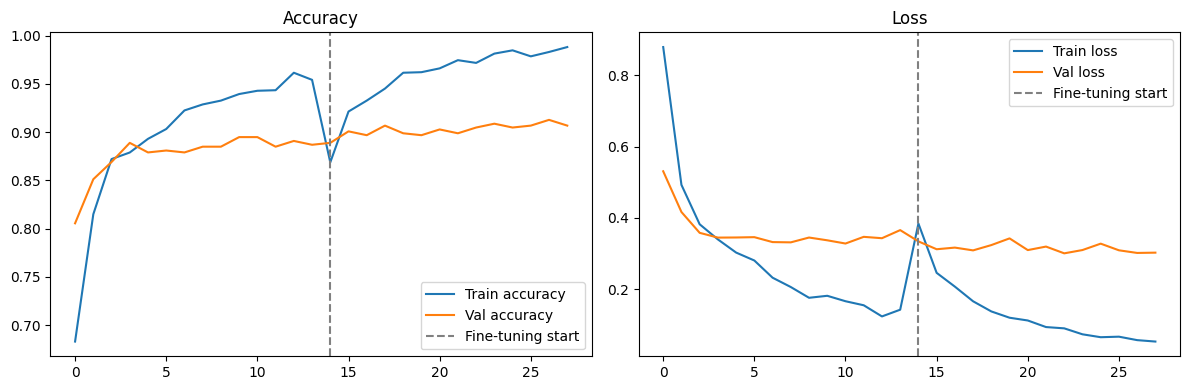

              precision    recall  f1-score   support

   cardboard       0.95      0.95      0.95        44
       glass       0.89      0.89      0.89        47
       metal       0.90      0.93      0.91        40
       paper       0.92      0.91      0.91        64
     plastic       0.84      0.84      0.84        44
       trash       0.64      0.64      0.64        14

    accuracy                           0.89       253
   macro avg       0.86      0.86      0.86       253
weighted avg       0.89      0.89      0.89       253



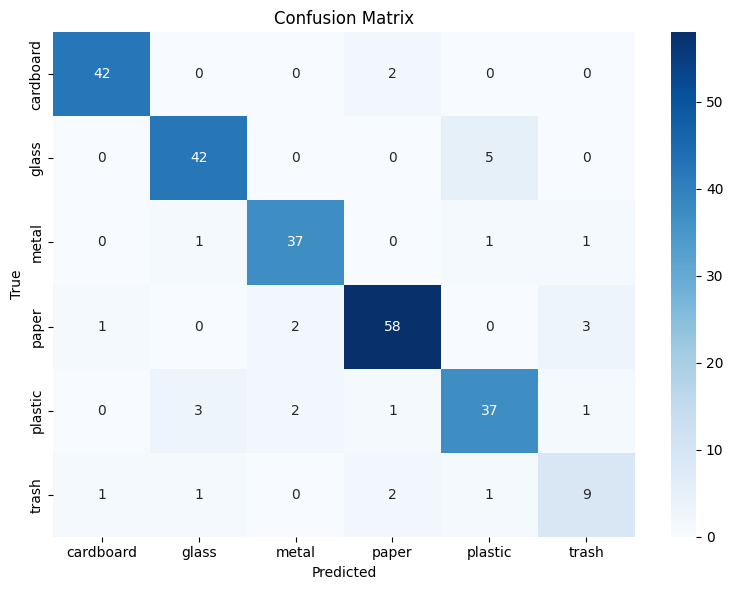

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Wykresy treningu
def plot_history(h1, h2):
    acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(acc, label="Train accuracy")
    plt.plot(val_acc, label="Val accuracy")
    plt.axvline(x=len(h1.history["accuracy"]), color="gray", linestyle="--", label="Fine-tuning start")
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(loss, label="Train loss")
    plt.plot(val_loss, label="Val loss")
    plt.axvline(x=len(h1.history["loss"]), color="gray", linestyle="--", label="Fine-tuning start")
    plt.legend()
    plt.title("Loss")
    
    plt.tight_layout()
    plt.show()

plot_history(history1, history2)

# Macierz pomyłek
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()